In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re
from scipy import optimize
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pickle as pkl
from matplotlib.lines import Line2D
import collections
from collections import defaultdict


In [4]:
## Define functions
def rename_samples_scan(df):
    df.columns = [re.sub('SCAN1807','SCAN1807.haemolysed',col)for col in df.columns]
    df.columns = [re.sub('SCAN1818','SCAN1818.haemolysed',col)for col in df.columns]
    df.columns = [re.sub('SCAN1819','SCAN1819.haemolysed',col)for col in df.columns]
    df.columns = [re.sub('SCAN3439','SCAN3439.Stomach_tumour',col)for col in df.columns]
    df.columns = [re.sub('SCAN3444','SCAN3444.Lung_tumour',col)for col in df.columns]
    df.columns = [re.sub('SCAN3616','SCAN3616.Colon_tumour',col)for col in df.columns]
    df.columns = [re.sub('SCAN3468','SCAN3468.Pancreas_tumour',col)for col in df.columns]
    return df


def rename_samples_dimitrios(df):
    df.columns = [re.sub("organism_part", "biosample_idcase_control_organism_part",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL062CF-B15-220613", "CRC_stage_3_S01-TS-GEL062CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL063-CF-B10-220111", "CRC_stage_2_S01-TS-GEL063-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL066-CF-B10-220111", "CRC_stage_2_S02-TS-GEL066-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL075CF-B15-220613", "CRC_stage_2_S02-TS-GEL075CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL099CF-B16-220708", "OVR_stage_3_S05-TS-GEL099CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-GEL106CF-B15-220613", "CRC_stage_3_S03-TS-GEL106CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL107CF-B13-220314", "CRC_stage_3_S07-TS-GEL107CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-GEL121-CF-B10-220111", "CRC_stage_3_S03-TS-GEL121-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL140CF-B15-220613", "CRC_stage_3_S04-TS-GEL140CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL160CF-B15-220613", "CRC_stage_3_S05-TS-GEL160CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL163CF-B13-220314", "CRC_stage_2_S02-TS-GEL163CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL174CF-B16-220708", "OVR_stage_3_S06-TS-GEL174CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL190CF-B15-220613", "CRC_stage_2_S06-TS-GEL190CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL191CF-B16-220708", "RNL_stage_3_S09-TS-GEL191CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL193CF-B15-220613", "CRC_stage_3_S07-TS-GEL193CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL194CF-B16-221021", "RNL_stage_1a_S07-TS-GEL194CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL195-PRE-CF-B16-221018", "CRC_stage_3_S06-TS-GEL195-PRE-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL197-PRE-CF-B16-221018", "CRC_stage_2_S07-TS-GEL197-PRE-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL200CF-B16-221021", "RNL_stage_2a_S08-TS-GEL200CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL205-PRE-CF-B16-221018", "CRC_stage_3_S04-TS-GEL205-PRE-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL216-CF-B10-220111", "RNL_stage_3_S04-TS-GEL216-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL217CF-B15-220613", "CRC_stage_3_S08-TS-GEL217CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL223-PRE-CF-B16-221018", "CRC_stage_3_S05-TS-GEL223-PRE-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL237CF-B16-221021", "RNL_stage_3a_S09-TS-GEL237CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL254CF-B13-220314", "CRC_stage_3_S09-TS-GEL254CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL270CF-B15-220613", "CRC_stage_2_S09-TS-GEL270CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S10-TS-GEL282-PRE-CF-B16-221021", "CRC_stage_4_S10-TS-GEL282-PRE-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL287CF-B16-220708", "CRC_stage_3_S01-TS-GEL287CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL295CF-B16-220708", "CRC_stage_3_S02-TS-GEL295CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-GEL297CF-B16-220708", "CRC_stage_2_S03-TS-GEL297CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL302CF-B16-220708", "CRC_stage_3_S04-TS-GEL302CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL314CF-B13-220314", "CRC_stage_2_S01-TS-GEL314CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL316CF-B16-220708", "OVR_stage_1_S07-TS-GEL316CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL320CF-B13-220314", "CRC_stage_3_S08-TS-GEL320CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL323CF-B16-220708", "CRC_stage_3_S05-TS-GEL323CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL329CF-B16-220708", "CRC_stage_2_S06-TS-GEL329CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL336CF-B16-220708", "OVR_stage_3_S08-TS-GEL336CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL339CF-B13-220314", "CRC_stage_3_S05-TS-GEL339CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL349CF-B16-220708", "CRC_stage_2_S07-TS-GEL349CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL350CF-B16-220708", "CRC_stage_3_S08-TS-GEL350CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL370CF-B16-220708", "CRC_stage_3_S09-TS-GEL370CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL381CF-B16-220708", "CRC_stage_3_S01-TS-GEL381CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL403CF-B13-220314", "PNCR_stage_3_S02-TS-GEL403CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL414CF-B16-220708", "OES_stage_3_S02-TS-GEL414CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL424-CF-B10-220111", "PNCR_stage_3_S05-TS-GEL424-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL432CF-B13-220314", "CRC_stage_3_S06-TS-GEL432CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL444CF-B13-220314", "PNCR_stage_2_S04-TS-GEL444CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-GEL447CF-B16-220708", "OES_stage_3_S03-TS-GEL447CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL498CF-B13-220314", "OES_stage_2_S01-TS-GEL498CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL521-CF-B10-220111", "PNCR_stage_1_S06-TS-GEL521-CF-B10-220111",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL530CF-B13-220311", "OES_stage_3_S06-TS-GEL530CF-B13-220311",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-GEL533CF-B13-220314", "PNCR_stage_3_S03-TS-GEL533CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-GEL546CF-B16-220708", "OES_stage_3_S04-TS-GEL546CF-B16-220708",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL571CF-B13-220311", "OES_stage_2_S09-TS-GEL571CF-B13-220311",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL583CF-B13-220311", "OES_stage_2_S07-TS-GEL583CF-B13-220311",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL588CF-B13-220311", "OES_stage_2_S08-TS-GEL588CF-B13-220311",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-SCAN051CF-B15-220610", "SCAN_stage_Non-cancer_S01-TS-SCAN051CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-SCAN055CF-B13-220314", "SCAN_stage_Non-cancer_S05-TS-SCAN055CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-SCAN063CF-B15-220610", "SCAN_stage_Non-cancer_S02-TS-SCAN063CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-SCAN071CF-B13-220314", "SCAN_stage_Non-cancer_S06-TS-SCAN071CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-SCAN073CF-B13-220314", "SCAN_stage_Non-cancer_S08-TS-SCAN073CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-SCAN077CF-B15-220610", "BRST_stage_1_S03-TS-SCAN077CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-SCAN079CF-B15-220610", "SCAN_stage_Non-cancer_S04-TS-SCAN079CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-SCAN098CF-B15-220610", "SCAN_stage_Non-cancer_S05-TS-SCAN098CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-SCAN100CF-B15-220610", "SCAN_stage_Non-cancer_S06-TS-SCAN100CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-SCAN102CF-B15-220610", "SCAN_stage_Non-cancer_S07-TS-SCAN102CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-SCAN103CF-B15-220610", "SCAN_stage_Non-cancer_S08-TS-SCAN103CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-SCAN105CF-B15-220610", "SCAN_stage_Non-cancer_S09-TS-SCAN105CF-B15-220610",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-SCAN1051CF-B16-221018", "PNCR_stage_2_S01-TS-SCAN1051CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-SCAN107CF-B15-220613", "BRST_stage_2_S01-TS-SCAN107CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-SCAN108CF-B15-220613", "SCAN_stage_Non-cancer_S02-TS-SCAN108CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-SCAN109CF-B15-220613", "SCAN_stage_Non-cancer_S03-TS-SCAN109CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-SCAN111CF-B15-220613", "SCAN_stage_Non-cancer_S04-TS-SCAN111CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-SCAN115CF-B15-220613", "SCAN_stage_Non-cancer_S05-TS-SCAN115CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-SCAN116CF-B15-220613", "SCAN_stage_Non-cancer_S06-TS-SCAN116CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-SCAN117CF-B15-220613", "SCAN_stage_Non-cancer_S07-TS-SCAN117CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-SCAN122CF-B15-220613", "SCAN_stage_Non-cancer_S08-TS-SCAN122CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-SCAN123CF-B15-220613", "SCAN_stage_Non-cancer_S09-TS-SCAN123CF-B15-220613",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-SCAN1282CF-B16-221018", "CRC_stage_1_S02-TS-SCAN1282CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-SCAN1333CF-B16-221018", "CRC_stage_2_S03-TS-SCAN1333CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-SCAN135CF-B13-220314", "SCAN_stage_Non-cancer_S07-TS-SCAN135CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-SCAN543CF-B13-220314", "SCAN_stage_Non-cancer_S09-TS-SCAN543CF-B13-220314",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-CBHC1-CF-B16-221123", "CBHC_stage_Non-cancer_S01-TS-CBHC1-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-CBHC2-CF-B16-221123", "CBHC_stage_Non-cancer_S02-TS-CBHC2-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S03-TS-CBHC3-CF-B16-221123", "CBHC_stage_Non-cancer_S03-TS-CBHC3-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S04-TS-CBHC4-CF-B16-221123", "CBHC_stage_Non-cancer_S04-TS-CBHC4-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-CBHC5-CF-B16-221123", "CBHC_stage_Non-cancer_S05-TS-CBHC5-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-CBHC6-CF-B16-221123", "CBHC_stage_Non-cancer_S06-TS-CBHC6-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-CBHC7-CF-B16-221123", "CBHC_stage_Non-cancer_S07-TS-CBHC7-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-CBHC8-CF-B16-221123", "CBHC_stage_Non-cancer_S08-TS-CBHC8-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-CBHC9-CF-B16-221123", "CBHC_stage_Non-cancer_S09-TS-CBHC9-CF-B16-221123",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL066-FU1-CF-B16-221018", "CRC_stage_2_S09-TS-GEL066-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S10-TS-GEL066-FU2-CF-B16-221018", "CRC_stage_2_S10-TS-GEL066-FU2-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL107-FU1-CF-B16-221018", "CRC_stage_3_S01-TS-GEL107-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL193-FU1-CF-B16-221021", "CRC_stage_3_S01-TS-GEL193-FU1-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S10-TS-GEL195-FU1-CF-B16-221018", "CRC_stage_3_S10-TS-GEL195-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL197-FU1-CF-B16-221018", "CRC_stage_2_S08-TS-GEL197-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S05-TS-GEL205-FU1-CF-B16-221018", "CRC_stage_3_S05-TS-GEL205-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S06-TS-GEL205-FU2-CF-B16-221018", "CRC_stage_3_S06-TS-GEL205-FU2-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL223-FU1-CF-B16-221018", "CRC_stage_3_S07-TS-GEL223-FU1-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL223-FU2-CF-B16-221018", "CRC_stage_3_S08-TS-GEL223-FU2-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL223-FU3-CF-B16-221018", "CRC_stage_3_S09-TS-GEL223-FU3-CF-B16-221018",col)for col in df.columns]
    df.columns = [re.sub("S01-TS-GEL282-FU1-CF-B16-221021", "CRC_stage_4_S01-TS-GEL282-FU1-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S02-TS-GEL282-FU2-CF-B16-221021", "CRC_stage_4_S02-TS-GEL282-FU2-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S07-TS-GEL339-FU1-CF-B16-221021", "CRC_stage_3_S07-TS-GEL339-FU1-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S08-TS-GEL432-FU1-CF-B16-221021", "CRC_stage_3_S08-TS-GEL432-FU1-CF-B16-221021",col)for col in df.columns]
    df.columns = [re.sub("S09-TS-GEL432-FU2-CF-B16-221021", "CRC_stage_3_S09-TS-GEL432-FU2-CF-B16-221021",col)for col in df.columns]    
    return df

def heatmap_auto_size(df, per_sample=0.6, per_row=0.35,
                      pad_lr=2.0, pad_tb=1.0,
                      min_w=6, max_w=40, min_h=3, max_h=30,
                      **hm_kwargs):
    n_samples = df.shape[1]
    n_rows = df.shape[0]
    # width scales with number of samples; height with number of rows
    width  = pad_lr + per_sample * n_samples
    height = pad_tb + per_row   * n_rows
    # clamp so it doesn't get absurdly small/large
    width  = max(min_w, min(max_w, width))
    height = max(min_h, min(max_h, height))
    return width, height

In [1]:
# --- imports ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

# --- inputs ---
### Load atlas ###
meth_atlas_tissues_fn = "/users/ludwig/cfo155/cfo155/tissueMap/methcalls/dmr_call_new1/all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt"
meth_atlas_tissues = pd.read_csv(meth_atlas_tissues_fn, sep="\t").set_index(['chr', 'start', 'end'])

# --- build per-tissue .mean columns (invert if mark is umC) ---
# Infer mark from filename (adjust if you want to force it)
if ".umC." in meth_atlas_tissues_fn:
    mark = "umC"
elif ".hmC." in meth_atlas_tissues_fn:
    mark = "hmC"
else:
    mark = "mC"

# DMR direction to keep later
sel_dmr = "Hypo" if mark == "mC" else "Hyper"


rep_cols = meth_atlas_tissues.columns[:116]
all_tissue_types = sorted(set(re.sub(r'.*_', '', c) for c in rep_cols))

for tissue in all_tissue_types:
    # print(tissue)
    # columns that END with _<tissue>
    cols = [c for c in rep_cols if c.endswith('_' + tissue)]
    # print(cols)
    if not cols:
        continue
    row_mean = meth_atlas_tissues[cols].mean(axis=1)
    if mark == "umC":
        row_mean = (1.0 - row_mean)*100
    meth_atlas_tissues[f"{tissue}.mean"] = row_mean




In [5]:
sel_N = 200
top_by_tissue = (
    meth_atlas_tissues
      .sort_values('delta_quants', ascending=False)
      .groupby('selected_tissue', group_keys=False)
      .head(sel_N)          # take top-N per group; ties are truncated arbitrarily
)
### Load SCAN cfDNA ###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.SCAN_cfTAPS.samples.filtered.CpG.rC.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])

samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
samples_df = rename_samples_scan(samples_df)

# --- filter atlas rows/columns ---
exclude_tissues = [
    'Pancreas-Pancreatitis', 'Liver-Cirrhosis',
    'Ovary-Tumour','Kidney-Tumour','Prostate-Tumour','Breast-Tumour', 'Liver-Tumour', 'Brain-Tumour'
    # 'Colon-Tumour','Stomach-Tumour','Lung-Tumour','Pancreas-Tumour',
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]

top_by_tissue_filtered = df.loc[row_mask, keep_cols].copy()/100


In [13]:
df.filter(like='.mean', axis=1).to_csv(re.sub(r'\.txt$',f'.selN{sel_N}.cfDNA_reference.txt', meth_atlas_tissues_fn), index=True, float_format='%.4f')


In [92]:
sel_N = 200
top_by_tissue = (
    meth_atlas_tissues
      .sort_values('delta_quants', ascending=False)
      .groupby('selected_tissue', group_keys=False)
      .head(sel_N)          # take top-N per group; ties are truncated arbitrarily
)

### Load cfTAPS cfDNA (this include deliver patients)###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.all_CpG.rC.TAPS.20snprm.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])
samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
samples_df = samples_df.loc[:, ~samples_df.columns.str.contains("NH125|NH134|NH140|NH159|NH160")]

# --- filter atlas rows/columns ---
exclude_tissues = [
    'Pancreas-Pancreatitis',
    'Ovary-Tumour','Kidney-Tumour','Brain-Tumour','Prostate-Tumour','Breast-Tumour','Colon-Tumour','Stomach-Tumour','Lung-Tumour',
    # 'Pancreas-Tumour','Liver-Tumour', 'Liver-Cirrhosis'
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]

top_by_tissue_filtered = df.loc[row_mask, keep_cols].copy()


In [52]:
### Load cfTAPS cfDNA (from Science Advances)###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.cfTAPS_paper_CpG_meth_count.clip.10.140.75.75.filtered.rC.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])
samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
samples_df.columns = [re.sub('Healthy_NHCCJORO037','Cirrhosis_NHCCJORO037',col)for col in samples_df.columns]
samples_df = samples_df.loc[:, ~samples_df.columns.str.contains("NHCCKAMI035")]
#NHCCKAMI035
# --- filter atlas rows/columns ---
exclude_tissues = [
    'Pancreas-Pancreatitis', 
    'Ovary-Tumour','Kidney-Tumour','Brain-Tumour','Prostate-Tumour','Breast-Tumour','Colon-Tumour','Stomach-Tumour','Lung-Tumour',
    # 'Pancreas-Tumour','Liver-Tumour', 'Liver-Cirrhosis',
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]
top_by_tissue_filtered = df.loc[row_mask, keep_cols].copy()

In [114]:
### Load cfWGBS cfDNA (Cancerdetector)###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.all_meth.cancerdetector.rC.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])
samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
# --- filter atlas rows/columns ---
exclude_tissues = [
    'Pancreas-Pancreatitis', 'Liver-Cirrhosis',
    'Pancreas-Tumour', 'Ovary-Tumour','Kidney-Tumour','Brain-Tumour','Prostate-Tumour','Breast-Tumour','Colon-Tumour','Stomach-Tumour','Lung-Tumour',
    # 'Liver-Tumour', 
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]
top_by_tissue_filtered = df.loc[row_mask, keep_cols].copy()

In [ ]:
top_by_tissue_filtered

In [60]:
### Load cfTAPS Dimitrios ###
samples_fn = "all_sample.merged.mlml.mincov10_common.groupby.hg38_ws1000.s500.umC.bgQ0.05-0.05.tgQ0.25.hyper_dmrs.bg_quant_modegroups.all.txt.cfTAPS_NC_2025.filtered.CpG.rC.txt"
samples_df = pd.read_csv(samples_fn, sep="\t").set_index(['chr', 'start', 'end'])
samples_df = samples_df.filter(like="rC").groupby(['chr', 'start', 'end'],dropna=True).mean()
samples_df = rename_samples_dimitrios(samples_df)
# --- filter atlas rows/columns ---
exclude_tissues = [
    'Liver-Cirrhosis', 'Pancreas-Pancreatitis','Brain-Tumour','Prostate-Tumour','Stomach-Tumour','Lung-Tumour','Liver-Tumour','Ovary-Tumour','Kidney-Tumour','Breast-Tumour','Pancreas-Tumour'
    # 'Colon-Tumour',
]

df = top_by_tissue

# Expect these columns to exist in atlas:
#   'selected_tissue' & 'Hyper_or_Hypo'
row_mask = (~df['selected_tissue'].isin(exclude_tissues)) & (df['Hyper_or_Hypo'] == sel_dmr)

mean_cols = df.filter(like='.mean', axis=1).columns
bad_cols = {f"{t}.mean" for t in exclude_tissues}
keep_cols = [c for c in mean_cols if c not in bad_cols]
top_by_tissue_filtered = df.loc[row_mask, keep_cols].copy()

In [35]:
# ========== Deconvolution using rC inputs ==========
# Index join on (chr,start,end)
merged_rc = top_by_tissue_filtered.join(samples_df, how='inner')
atlas_df = merged_rc.filter(like='.mean', axis=1)
samples_rc_df = merged_rc.filter(like='rC', axis=1)

# Convert once
A_full = atlas_df.to_numpy(dtype=float)                 # shape: bins x tissues
base_mask = np.isfinite(A_full).all(axis=1)             # rows with finite atlas

sample_mixtures = pd.DataFrame(index=atlas_df.columns)  # rows=tissues
residuals = []

for sample_name in samples_rc_df.columns:
    b_full = samples_rc_df[sample_name].to_numpy(dtype=float)

    # keep rows finite in both A and b
    mask = base_mask & np.isfinite(b_full)
    A = A_full[mask, :]
    b = b_full[mask]
    print(sample_name)
    print(A.shape)
    print(b.shape)

    # optional: clip if you expect fractions
    # A = np.clip(A, 0, 1); b = np.clip(b, 0, 1)

    # need rows >= cols for a stable solve
    if A.shape[0] < A.shape[1]:
        print(f"Skip {sample_name}: not enough valid rows ({A.shape[0]}) "
              f"for {A.shape[1]} tissues.")
        continue

    w, res = optimize.nnls(A, b)
    s = w.sum()
    if s > 0:
        w = w / s
    sample_mixtures[sample_name] = w
    residuals.append(res)

# Tidy labels
sample_mixtures.index.name = 'atlas_tissues'
sample_mixtures.index = [re.sub(r'\.mean$', '', c) for c in sample_mixtures.index]
sample_mixtures.columns = [re.sub(r'\.rC$', '', c) for c in sample_mixtures.columns]

import re
def natsort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]

sample_mixtures = sample_mixtures.loc[:, sorted(sample_mixtures.columns, key=natsort_key)]
tissue_order_all = ["CD34-megakaryocytes","Neutrophils", "Monocytes","CD34-erythroblasts","CD4-T-cells", "CD8-T-cells", "NK-cells", "B-cells",  "Eosinophils",
                    "Brain", "Breast", "Heart", "Kidney", "Liver", "Lung", "Ovary", "Pancreas", "Prostate", "Colon", "Stomach", "Esophagus", "Spleen", 
                    "Liver-Cirrhosis", "Pancreas-Pancreatitis",
                    "Brain-Tumour", "Breast-Tumour", "Colon-Tumour", "Kidney-Tumour", "Liver-Tumour", "Pancreas-Tumour","Lung-Tumour",  "Ovary-Tumour",  "Prostate-Tumour","Stomach-Tumour"
                ]
exclude_set = set(exclude_tissues)  
tissue_order = [t for t in tissue_order_all if t not in exclude_set]
sample_mixtures = sample_mixtures.reindex(tissue_order).dropna(how="all")

sample_mixtures.to_csv(re.sub(r'\.txt$',f'.selN{sel_N}.tissue_contribution.txt', samples_fn), index=True, index_label='tissue', float_format='%.4f')
# Heatmap
width, height=heatmap_auto_size(sample_mixtures)
plt.figure(figsize=(width, height))
sns.heatmap(sample_mixtures, cmap='RdBu_r', annot=True, fmt='.2f', linewidths=0.5, annot_kws={"fontsize":8})
plt.title(f'selN{sel_N}Tissue contribution (hyper mC)', fontsize=16)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Tissues", fontsize=12)
plt.tight_layout()
plt.savefig(re.sub(r'\.txt$', f'.selN{sel_N}.tissue_contribution.pdf', samples_fn), format='pdf')
plt.savefig(re.sub(r'\.txt$', f'.selN{sel_N}.tissue_contribution.png', samples_fn), format='png', dpi=300)
plt.close()


SCAN1754.rC
(5199, 26)
(5199,)
SCAN1770.rC
(5188, 26)
(5188,)
SCAN1788.rC
(5197, 26)
(5197,)
SCAN1793.rC
(5200, 26)
(5200,)
SCAN1794.rC
(5200, 26)
(5200,)
SCAN1796.rC
(5199, 26)
(5199,)
SCAN1804.rC
(5200, 26)
(5200,)
SCAN1805.rC
(5152, 26)
(5152,)
SCAN1807.haemolysed.rC
(5200, 26)
(5200,)
SCAN1816.rC
(5162, 26)
(5162,)
SCAN1817.rC
(5034, 26)
(5034,)
SCAN1818.haemolysed.rC
(5200, 26)
(5200,)
SCAN1819.haemolysed.rC
(5199, 26)
(5199,)
SCAN1829.rC
(5200, 26)
(5200,)
SCAN1831.rC
(5200, 26)
(5200,)
SCAN1832.rC
(5200, 26)
(5200,)
SCAN3439.Stomach_tumour.rC
(5199, 26)
(5199,)
SCAN3444.Lung_tumour.rC
(5200, 26)
(5200,)
SCAN3468.Pancreas_tumour.rC
(5200, 26)
(5200,)
SCAN3616.Colon_tumour.rC
(5200, 26)
(5200,)


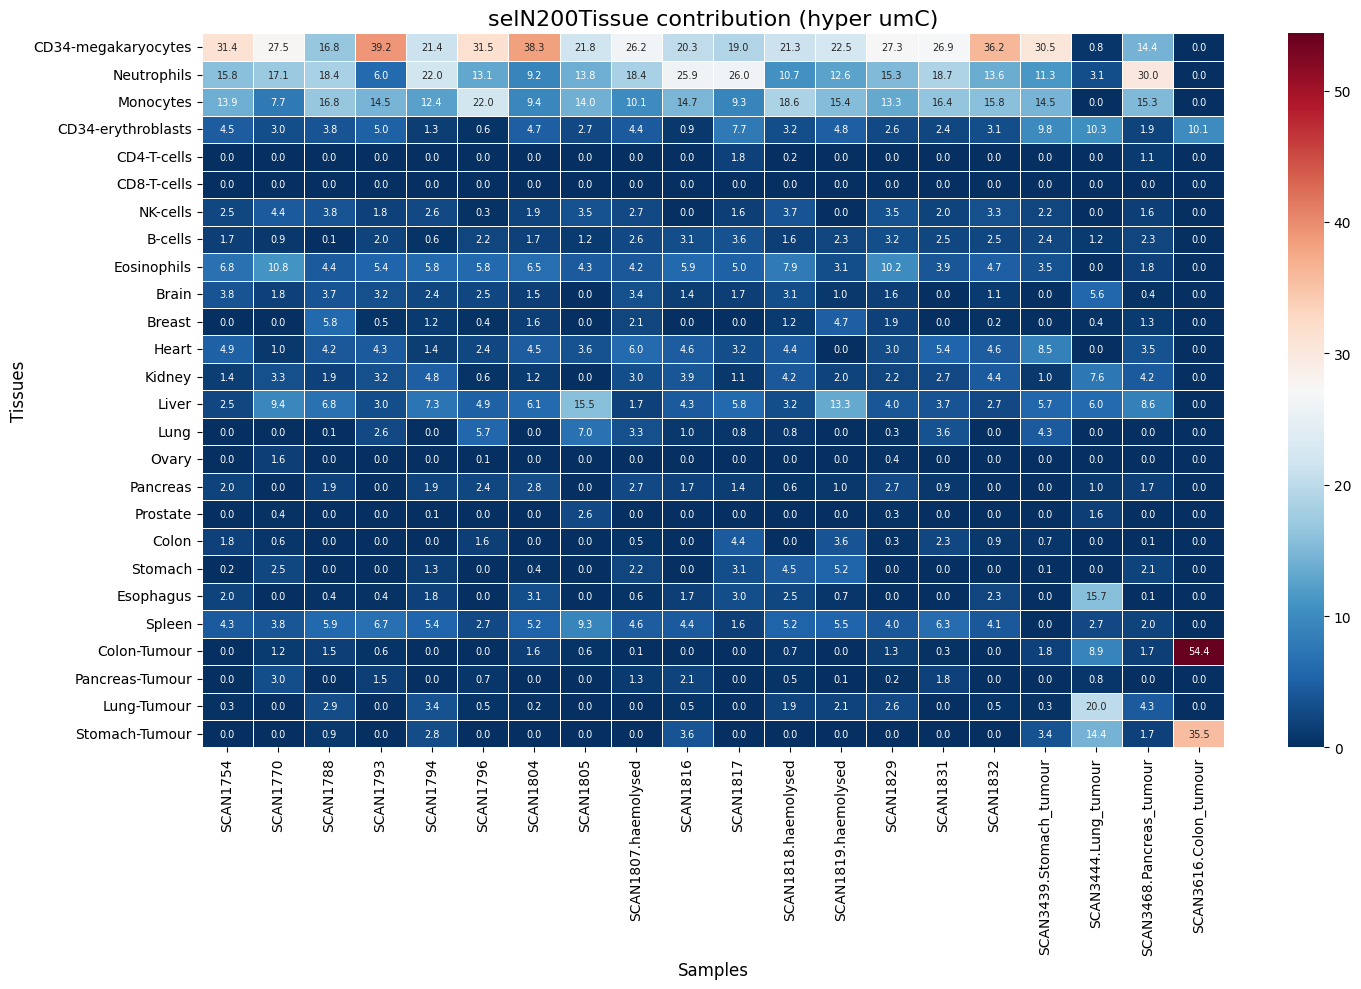

In [36]:
fig, ax = plt.subplots(figsize=(15, 10))

# sns.heatmap(sample_mixtures, cmap='RdBu_r', linewidths=0.5,
#             annot_kws={"fontsize": 8}, ax=ax)
sns.heatmap(sample_mixtures*100, cmap='RdBu_r', annot=True, fmt='.1f', linewidths=0.5, annot_kws={"fontsize":7})
plt.title(f'selN{sel_N}Tissue contribution (hyper umC)', fontsize=16)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Tissues", fontsize=12)

# ---- SHOW ALL ROW NAMES ----
ax.set_yticks(np.arange(len(sample_mixtures.index)) + 0.5)
ax.set_yticklabels(sample_mixtures.index, rotation=0)

# ---- SHOW ALL COLUMN NAMES ----
ax.set_xticks(np.arange(len(sample_mixtures.columns)) + 0.5)
ax.set_xticklabels(sample_mixtures.columns, rotation=90)

plt.tight_layout()
plt.show()


Group counts:
 Group
CRC_stage34    36
Healthy        30
CRC_stage12    16
Name: count, dtype: int64

=== T-test Results (Welch) ===
CRC_stage12 vs CRC_stage34: TtestResult(statistic=np.float64(-1.0798903648406413), pvalue=np.float64(0.2871124380078296), df=np.float64(37.365144294712955))
Healthy vs CRC_stage12: TtestResult(statistic=np.float64(-0.23659530864206896), pvalue=np.float64(0.8153486595291626), df=np.float64(20.240964778436553))
Healthy vs CRC_stage34: TtestResult(statistic=np.float64(-1.7479512281165779), pvalue=np.float64(0.08669046859903927), df=np.float64(49.361528879258586))

=== Mann-Whitney U (Wilcoxon rank-sum) Results ===
CRC_stage12 vs CRC_stage34: MannwhitneyuResult(statistic=np.float64(224.0), pvalue=np.float64(0.19678414937881383))
Healthy vs CRC_stage12: MannwhitneyuResult(statistic=np.float64(262.0), pvalue=np.float64(0.6070647554930899))
Healthy vs CRC_stage34: MannwhitneyuResult(statistic=np.float64(477.0), pvalue=np.float64(0.41434409892462454))


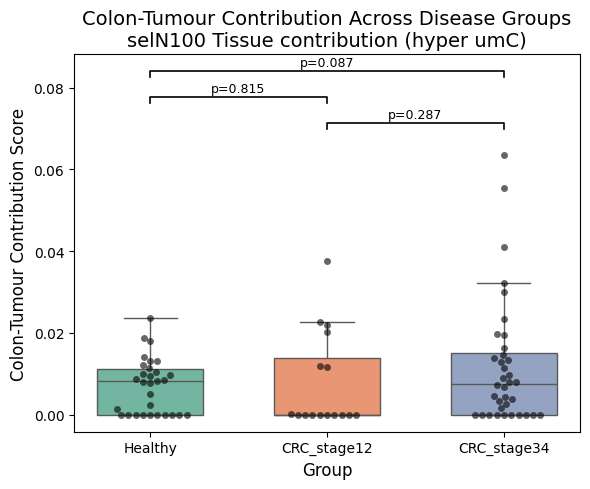

In [73]:
### Load cfTAPS Dimitrios ###
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

# ------------- Config ----------------
sel_tissue_type = "Colon-Tumour"   # must match a row in sample_mixtures.index
# --------------------------------------

# 1) Load your mixture matrix
df = sample_mixtures.copy()

# 2) Extract contributions for the selected tissue row
if sel_tissue_type not in df.index:
    raise KeyError(f"Row '{sel_tissue_type}' not found. Available rows: {list(df.index)[:20]} ...")
vals = df.loc[sel_tissue_type]     # Series: index=sample names

# 3) Classify sample groups based on column names
def classify_sample(colname):
    # detect stage 1 or 2
    if re.search(r"CRC_stage_1|CRC_stage_2", colname, re.IGNORECASE):
        return "CRC_stage12"
    # detect stage 3 or 4
    elif re.search(r"CRC_stage_3|CRC_stage_4", colname, re.IGNORECASE):
        return "CRC_stage34"
    # healthy / non-cancer
    elif re.search(r"Non-cancer", colname, re.IGNORECASE):
        return "Healthy"
    else:
        return "Other"

groups = vals.index.to_series().apply(classify_sample)

# Keep only the three groups of interest
keep_groups = ["Healthy", "CRC_stage12", "CRC_stage34"]
mask = groups.isin(keep_groups)
vals = vals[mask]
groups = groups[mask]

# 4) Build tidy DataFrame (column name = sel_tissue_type)
data = pd.DataFrame({
    sel_tissue_type: vals.values,
    "Group": groups.values
})

print("Group counts:\n", data["Group"].value_counts())

# 5) Extract values for tests (use names that match current groups)
g_healthy = data.loc[data["Group"] == "Healthy", sel_tissue_type]
g_12 = data.loc[data["Group"] == "CRC_stage12", sel_tissue_type]
g_34 = data.loc[data["Group"] == "CRC_stage34", sel_tissue_type]

def safe_ttest(a, b):
    if len(a) < 2 or len(b) < 2:
        return None
    return ttest_ind(a, b, equal_var=False)

def safe_mannwhitney(a, b):
    try:
        if len(a) < 1 or len(b) < 1:
            return None
        return mannwhitneyu(a, b, alternative="two-sided")
    except Exception:
        return None

tt_12_vs_34 = safe_ttest(g_12, g_34)
tt_Healthy_vs_12 = safe_ttest(g_healthy, g_12)
tt_Healthy_vs_34 = safe_ttest(g_healthy, g_34)

mw_12_vs_34 = safe_mannwhitney(g_12, g_34)
mw_Healthy_vs_12 = safe_mannwhitney(g_healthy, g_12)
mw_Healthy_vs_34 = safe_mannwhitney(g_healthy, g_34)

print("\n=== T-test Results (Welch) ===")
print("CRC_stage12 vs CRC_stage34:", tt_12_vs_34)
print("Healthy vs CRC_stage12:", tt_Healthy_vs_12)
print("Healthy vs CRC_stage34:", tt_Healthy_vs_34)

print("\n=== Mann-Whitney U (Wilcoxon rank-sum) Results ===")
print("CRC_stage12 vs CRC_stage34:", mw_12_vs_34)
print("Healthy vs CRC_stage12:", mw_Healthy_vs_12)
print("Healthy vs CRC_stage34:", mw_Healthy_vs_34)

# ---------------------------
# 6) Plot with correct ordering
# ---------------------------

order = ["Healthy", "CRC_stage12", "CRC_stage34"]

fig, ax = plt.subplots(figsize=(6,5))

sns.boxplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    hue="Group",
    palette="Set2",
    dodge=False,
    order=order,
    ax=ax,
    showfliers=False,
    width=0.6
)
# remove legend produced by hue
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.swarmplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    order=order,
    color="k",
    alpha=0.6,
    ax=ax
)

# optional inclusion of sel_N in title if defined elsewhere
if 'sel_N' in globals():
    title = f"{sel_tissue_type} Contribution Across Disease Groups\nselN{sel_N} Tissue contribution (hyper umC)"
else:
    title = f"{sel_tissue_type} Contribution Across Disease Groups"

plt.title(title, fontsize=14)
plt.ylabel(f"{sel_tissue_type} Contribution Score", fontsize=12)
plt.xlabel("Group", fontsize=12)

# 7) Significance annotations using the same order
ymax = data[sel_tissue_type].max() if not data.empty else 0.0
ymin = data[sel_tissue_type].min() if not data.empty else 0.0
yrange = max(ymax - ymin, 1e-6)
gap = yrange * 0.1

# x positions according to 'order'
x_positions = {name: i for i, name in enumerate(order)}

def add_pval_annotation(x1_name, x2_name, pval, y_base):
    if x1_name not in x_positions or x2_name not in x_positions:
        return
    x1 = x_positions[x1_name]
    x2 = x_positions[x2_name]
    if pval is None:
        label = "n<2"
    else:
        # p may be in result object (ttest result) or tuple-like (older MW)
        try:
            pval_num = pval.pvalue
        except Exception:
            try:
                pval_num = pval[1]
            except Exception:
                pval_num = float(pval)
        label = f"p={pval_num:.3e}" if pval_num < 0.001 else f"p={pval_num:.3f}"
    h = yrange * 0.02
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y_base + h + (yrange * 0.01), label, ha='center', va='bottom', fontsize=9)

# stack annotation heights so they don't overlap
base_levels = [ymax + gap * i for i in range(1, 4)]

# Draw pairwise comparisons (adapt names to your question)
add_pval_annotation("CRC_stage12", "CRC_stage34", tt_12_vs_34 or mw_12_vs_34, base_levels[0])
add_pval_annotation("Healthy", "CRC_stage12", tt_Healthy_vs_12 or mw_Healthy_vs_12, base_levels[1])
add_pval_annotation("Healthy", "CRC_stage34", tt_Healthy_vs_34 or mw_Healthy_vs_34, base_levels[2])

plt.tight_layout()
plt.show()


Group counts:
 Group
Healthy      30
HCC          21
Cirrhosis     4
Name: count, dtype: int64

=== T-test Results ===
Healthy vs Cirrhosis: TtestResult(statistic=np.float64(-4.912826450614823), pvalue=np.float64(0.004817903113811706), df=np.float64(4.844802933742982))
Healthy vs HCC: TtestResult(statistic=np.float64(-3.3245176199978452), pvalue=np.float64(0.0030890981548736367), df=np.float64(21.914958668746447))
Cirrhosis vs HCC: TtestResult(statistic=np.float64(-1.0134684737034425), pvalue=np.float64(0.32140573477865747), df=np.float64(22.943257694451173))

=== Mann-Whitney U (Wilcoxon rank-sum) Results ===
Healthy vs Cirrhosis: MannwhitneyuResult(statistic=np.float64(6.0), pvalue=np.float64(0.0011643953769190961))
Healthy vs HCC: MannwhitneyuResult(statistic=np.float64(71.0), pvalue=np.float64(3.1568682308776193e-06))
Cirrhosis vs HCC: MannwhitneyuResult(statistic=np.float64(46.0), pvalue=np.float64(0.802687747035573))


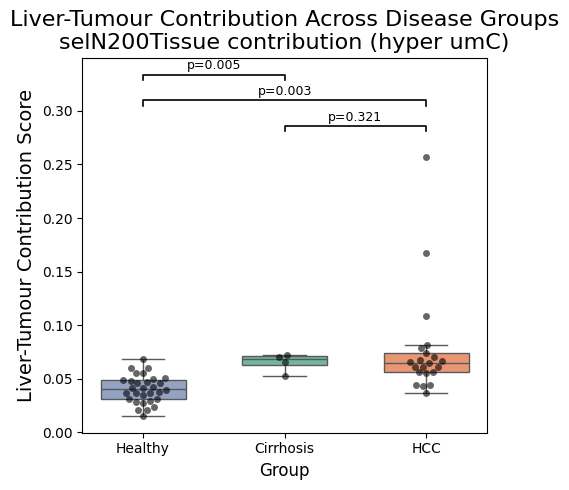

In [59]:
### Load cfTAPS cfDNA (from Science Advances)###
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# ------------- Config ----------------
sel_tissue_type = "Liver-Tumour"   # must match a row in sample_mixtures.index
# --------------------------------------

# 1) Load your mixture matrix
df = sample_mixtures.copy()

# 2) Extract contributions for the selected tissue row
vals = df.loc[sel_tissue_type]     # Series: index=sample names

# 3) Classify sample groups based on column names
def classify_sample(colname):
    if re.search("Cirrhosis", colname, re.IGNORECASE):
        return "Cirrhosis"
    elif re.search(r"\bHCC\b|HCC_", colname, re.IGNORECASE):
        return "HCC"
    elif re.search("Healthy|Normal|Control", colname, re.IGNORECASE):
        return "Healthy"
    else:
        return "Other"

groups = vals.index.to_series().apply(classify_sample)

# Keep only the three groups of interest
mask = groups.isin(["Healthy", "Cirrhosis", "HCC"])
vals = vals[mask]
groups = groups[mask]

# 4) Build tidy DataFrame (column name = sel_tissue_type)
data = pd.DataFrame({
    sel_tissue_type: vals.values,
    "Group": groups.values
})

print("Group counts:\n", data["Group"].value_counts())

# 5) Extract values for t-tests
healthy = data.loc[data["Group"] == "Healthy", sel_tissue_type]
cirrhosis = data.loc[data["Group"] == "Cirrhosis", sel_tissue_type]
hcc = data.loc[data["Group"] == "HCC", sel_tissue_type]

def safe_ttest(a, b):
    if len(a) < 2 or len(b) < 2:
        return None
    return ttest_ind(a, b, equal_var=False)

def safe_mannwhitney(a, b):
    try:
        if len(a) < 1 or len(b) < 1:
            return None
        # two-sided Mann-Whitney U (Wilcoxon rank-sum)
        return mannwhitneyu(a, b, alternative="two-sided")
    except Exception:
        return None
ttest_H_vs_C = safe_ttest(healthy, cirrhosis)
ttest_H_vs_HCC = safe_ttest(healthy, hcc)
ttest_C_vs_HCC = safe_ttest(cirrhosis, hcc)

print("\n=== T-test Results ===")
print("Healthy vs Cirrhosis:", ttest_H_vs_C)
print("Healthy vs HCC:", ttest_H_vs_HCC)
print("Cirrhosis vs HCC:", ttest_C_vs_HCC)

mw_H_vs_C = safe_mannwhitney(healthy, cirrhosis)
mw_H_vs_HCC = safe_mannwhitney(healthy, hcc)
mw_C_vs_HCC = safe_mannwhitney(cirrhosis, hcc)


print("\n=== Mann-Whitney U (Wilcoxon rank-sum) Results ===")
print("Healthy vs Cirrhosis:", mw_H_vs_C)
print("Healthy vs HCC:", mw_H_vs_HCC)
print("Cirrhosis vs HCC:", mw_C_vs_HCC)
# ---------------------------
# 6) Plot with correct ordering
# ---------------------------

# If you prefer a fixed order, uncomment and set explicitly:
order = ["Healthy", "Cirrhosis", "HCC"]

fig, ax = plt.subplots(figsize=(5,5))

sns.boxplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    hue="Group",
    palette="Set2",
    dodge=False,
    order=order,
    ax=ax,
    showfliers=False,
    width=0.6
)
# remove legend produced by hue
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.swarmplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    order=order,
    color="k",
    alpha=0.6,
    ax=ax
)

plt.title(f"{sel_tissue_type} Contribution Across Disease Groups\nselN{sel_N}Tissue contribution (hyper umC)", fontsize=16)
plt.ylabel(f"{sel_tissue_type} Contribution Score", fontsize=14)
plt.xlabel("Group", fontsize=12)

# 7) Significance annotations using the same order
ymax = data[sel_tissue_type].max()
ymin = data[sel_tissue_type].min()
yrange = max(ymax - ymin, 1e-6)
gap = yrange * 0.1

# x positions according to 'order'
x_positions = {name: i for i, name in enumerate(order)}

def add_pval_annotation(x1_name, x2_name, pval, y_base):
    if x1_name not in x_positions or x2_name not in x_positions:
        return
    x1 = x_positions[x1_name]
    x2 = x_positions[x2_name]
    if pval is None:
        label = "n<2"
    else:
        label = f"p={pval:.3e}" if pval < 0.001 else f"p={pval:.3f}"
    h = yrange * 0.02
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y_base + h + (yrange * 0.01), label, ha='center', va='bottom', fontsize=9)

# stack annotation heights so they don't overlap
base_levels = [ymax + gap * i for i in range(1, 4)]

# Draw comparisons (use group NAMES so mapping is explicit)
add_pval_annotation("Cirrhosis", "HCC", ttest_C_vs_HCC.pvalue if ttest_C_vs_HCC else None, base_levels[0])
add_pval_annotation("Healthy", "HCC", ttest_H_vs_HCC.pvalue if ttest_H_vs_HCC else None, base_levels[1])
add_pval_annotation("Healthy", "Cirrhosis", ttest_H_vs_C.pvalue if ttest_H_vs_C else None, base_levels[2])

plt.tight_layout()
plt.show()


Group counts:
 Group
Cirrhosis    18
HCC          12
Healthy      10
Name: count, dtype: int64

=== T-test Results ===
Healthy vs Cirrhosis: TtestResult(statistic=np.float64(-1.752938922639152), pvalue=np.float64(0.0914704388381579), df=np.float64(25.840932113809984))
Healthy vs HCC: TtestResult(statistic=np.float64(-2.5733723832142315), pvalue=np.float64(0.023622813575101233), df=np.float64(12.596532034711444))
Cirrhosis vs HCC: TtestResult(statistic=np.float64(-1.6774141965826852), pvalue=np.float64(0.11463587891270223), df=np.float64(14.667495247907176))

=== Mann-Whitney U (Wilcoxon rank-sum) Results ===
Healthy vs Cirrhosis: MannwhitneyuResult(statistic=np.float64(58.0), pvalue=np.float64(0.13096449437037963))
Healthy vs HCC: MannwhitneyuResult(statistic=np.float64(19.0), pvalue=np.float64(0.007574042066784554))
Cirrhosis vs HCC: MannwhitneyuResult(statistic=np.float64(66.0), pvalue=np.float64(0.07894592208173579))


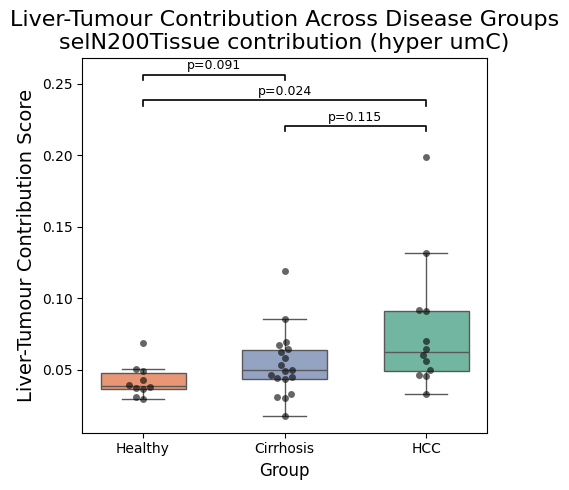

In [95]:
### Load cfTAPS cfDNA (this include deliver patients)###
from scipy.stats import ttest_ind, mannwhitneyu

# ------------- Config ----------------
sel_tissue_type = "Liver-Tumour"   # must match a row in sample_mixtures.index
# --------------------------------------

# 1) Load your mixture matrix
df = sample_mixtures.copy()

# 2) Extract contributions for the selected tissue row
vals = df.loc[sel_tissue_type]     # Series: index=sample names

# 3) Classify sample groups based on column names
def classify_sample(colname):
    if re.search("livercontrol", colname, re.IGNORECASE):
        return "Cirrhosis"
    elif re.search(r"\bHCC\b|HCC_", colname, re.IGNORECASE):
        return "HCC"
    elif re.search("healthycontrol", colname, re.IGNORECASE):
        return "Healthy"
    else:
        return "Other"

groups = vals.index.to_series().apply(classify_sample)

# Keep only the three groups of interest
mask = groups.isin(["Healthy", "Cirrhosis", "HCC"])
vals = vals[mask]
groups = groups[mask]

# 4) Build tidy DataFrame (column name = sel_tissue_type)
data = pd.DataFrame({
    sel_tissue_type: vals.values,
    "Group": groups.values
})

print("Group counts:\n", data["Group"].value_counts())

# 5) Extract values for t-tests
healthy = data.loc[data["Group"] == "Healthy", sel_tissue_type]
cirrhosis = data.loc[data["Group"] == "Cirrhosis", sel_tissue_type]
hcc = data.loc[data["Group"] == "HCC", sel_tissue_type]

def safe_ttest(a, b):
    if len(a) < 2 or len(b) < 2:
        return None
    return ttest_ind(a, b, equal_var=False)

def safe_mannwhitney(a, b):
    try:
        if len(a) < 1 or len(b) < 1:
            return None
        # two-sided Mann-Whitney U (Wilcoxon rank-sum)
        return mannwhitneyu(a, b, alternative="two-sided")
    except Exception:
        return None
ttest_H_vs_C = safe_ttest(healthy, cirrhosis)
ttest_H_vs_HCC = safe_ttest(healthy, hcc)
ttest_C_vs_HCC = safe_ttest(cirrhosis, hcc)

print("\n=== T-test Results ===")
print("Healthy vs Cirrhosis:", ttest_H_vs_C)
print("Healthy vs HCC:", ttest_H_vs_HCC)
print("Cirrhosis vs HCC:", ttest_C_vs_HCC)

mw_H_vs_C = safe_mannwhitney(healthy, cirrhosis)
mw_H_vs_HCC = safe_mannwhitney(healthy, hcc)
mw_C_vs_HCC = safe_mannwhitney(cirrhosis, hcc)


print("\n=== Mann-Whitney U (Wilcoxon rank-sum) Results ===")
print("Healthy vs Cirrhosis:", mw_H_vs_C)
print("Healthy vs HCC:", mw_H_vs_HCC)
print("Cirrhosis vs HCC:", mw_C_vs_HCC)
# ---------------------------
# 6) Plot with correct ordering
# ---------------------------

# If you prefer a fixed order, uncomment and set explicitly:
order = ["Healthy", "Cirrhosis", "HCC"]

fig, ax = plt.subplots(figsize=(5,5))

sns.boxplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    hue="Group",
    palette="Set2",
    dodge=False,
    order=order,
    ax=ax,
    showfliers=False,
    width=0.6
)
# remove legend produced by hue
if ax.get_legend() is not None:
    ax.get_legend().remove()

sns.swarmplot(
    data=data,
    x="Group",
    y=sel_tissue_type,
    order=order,
    color="k",
    alpha=0.6,
    ax=ax
)

plt.title(f"{sel_tissue_type} Contribution Across Disease Groups\nselN{sel_N}Tissue contribution (hyper umC)", fontsize=16)
plt.ylabel(f"{sel_tissue_type} Contribution Score", fontsize=14)
plt.xlabel("Group", fontsize=12)

# 7) Significance annotations using the same order
ymax = data[sel_tissue_type].max()
ymin = data[sel_tissue_type].min()
yrange = max(ymax - ymin, 1e-6)
gap = yrange * 0.1

# x positions according to 'order'
x_positions = {name: i for i, name in enumerate(order)}

def add_pval_annotation(x1_name, x2_name, pval, y_base):
    if x1_name not in x_positions or x2_name not in x_positions:
        return
    x1 = x_positions[x1_name]
    x2 = x_positions[x2_name]
    if pval is None:
        label = "n<2"
    else:
        label = f"p={pval:.3e}" if pval < 0.001 else f"p={pval:.3f}"
    h = yrange * 0.02
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y_base + h + (yrange * 0.01), label, ha='center', va='bottom', fontsize=9)

# stack annotation heights so they don't overlap
base_levels = [ymax + gap * i for i in range(1, 4)]

# Draw comparisons (use group NAMES so mapping is explicit)
add_pval_annotation("Cirrhosis", "HCC", ttest_C_vs_HCC.pvalue if ttest_C_vs_HCC else None, base_levels[0])
add_pval_annotation("Healthy", "HCC", ttest_H_vs_HCC.pvalue if ttest_H_vs_HCC else None, base_levels[1])
add_pval_annotation("Healthy", "Cirrhosis", ttest_H_vs_C.pvalue if ttest_H_vs_C else None, base_levels[2])

plt.tight_layout()
plt.show()


In [34]:
X_df

,CD34-megakaryocytes,Neutrophils,Monocytes,CD34-erythroblasts,CD4-T-cells,CD8-T-cells,NK-cells,B-cells,Eosinophils,Brain,...,Ovary,Pancreas,Prostate,Colon,Stomach,Esophagus,Spleen,Liver-Cirrhosis,Liver-Tumour,Pancreas-Tumour
HCC_NH125_rC,0.073118,0.050825,0.000000,0.068712,0.000000,0.0,0.025064,0.387226,0.018635,0.043720,...,0.000000,0.013059,0.000000,0.010675,0.025061,0.029567,0.005056,0.000000,0.064823,0.000000
HCC_NH126_rC,0.220172,0.075718,0.131779,0.044130,0.000000,0.0,0.032882,0.026755,0.038949,0.029613,...,0.000000,0.024781,0.000000,0.113628,0.041276,0.000061,0.048404,0.000000,0.055707,0.017654
HCC_NH127_rC,0.209837,0.181279,0.106570,0.041344,0.000000,0.0,0.034158,0.012488,0.079407,0.027835,...,0.000827,0.014936,0.000000,0.020768,0.018202,0.024186,0.081760,0.016861,0.060046,0.006108
HCC_NH128_rC,0.153163,0.307198,0.138045,0.013376,0.000000,0.0,0.024656,0.005839,0.058719,0.009573,...,0.000624,0.006048,0.000000,0.010553,0.000000,0.023569,0.044504,0.000000,0.091476,0.001481
HCC_NH131_rC,0.114643,0.296261,0.153443,0.054316,0.000000,0.0,0.020197,0.005917,0.056075,0.020865,...,0.000000,0.003035,0.007234,0.005466,0.024171,0.019252,0.022980,0.032835,0.064368,0.000000
HCC_NH132_rC,0.219318,0.049896,0.223441,0.024578,0.000000,0.0,0.011000,0.000000,0.044590,0.022895,...,0.006857,0.013965,0.004636,0.000199,0.022927,0.000359,0.049589,0.000000,0.198629,0.000000
HCC_NH133_rC,0.291695,0.060108,0.204210,0.017373,0.000000,0.0,0.024042,0.019888,0.098491,0.023379,...,0.000000,0.018786,0.000000,0.000000,0.026203,0.001480,0.060030,0.040059,0.032775,0.011628
HCC_NH134_rC,0.321906,0.064300,0.131215,0.083913,0.000000,0.0,0.047003,0.018533,0.059210,0.017698,...,0.000489,0.007914,0.000000,0.000000,0.019787,0.008910,0.037056,0.037206,0.042121,0.000000
HCC_NH137_rC,0.320902,0.136541,0.118051,0.045471,0.000000,0.0,0.030290,0.012263,0.073091,0.015541,...,0.000000,0.011935,0.000000,0.010738,0.000000,0.003831,0.047821,0.002777,0.049698,0.000362
HCC_NH140_rC,0.134311,0.067012,0.162095,0.024817,0.000000,0.0,0.016885,0.011479,0.060350,0.022991,...,0.000000,0.026771,0.005124,0.008736,0.000228,0.016524,0.027533,0.099648,0.094388,0.000000
